In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while ROOT.name != "RPG" and ROOT.parent != ROOT:
    ROOT = ROOT.parent

DATASETS = {
    "Sports": "sports",
    "CDs": "cds_and_vinyl",
    "Beauty": "beauty",
    "Toys": "toys_and_games",
}
GRAPH_ROOT = ROOT / "artifacts" / "rpg" / "graph_analysis"

In [2]:
def latest_session(dataset_slug: str) -> Path | None:
    root = GRAPH_ROOT / dataset_slug
    sessions = sorted(
        path
        for path in root.glob("*")
        if (path / "graphs" / "graph_metadata.json").is_file()
    )
    return sessions[-1] if sessions else None


def load_static(dataset_name: str, dataset_slug: str) -> pd.DataFrame:
    session = latest_session(dataset_slug)
    if session is None:
        return pd.DataFrame()
    path = session / "static" / "static_summary.csv"
    if not path.is_file():
        return pd.DataFrame()
    frame = pd.read_csv(path)
    frame.insert(0, "dataset", dataset_name)
    frame.insert(1, "session", str(session))
    if "n_nodes" in frame.columns:
        frame["k_over_items"] = frame["k"] / frame["n_nodes"]
    return frame


static = pd.concat(
    [load_static(name, slug) for name, slug in DATASETS.items()],
    ignore_index=True,
)

if static.empty:
    print("No static graph-analysis outputs found yet.")
else:
    display(static[["dataset", "k", "n_nodes", "n_edges", "k_over_items"]].drop_duplicates())

,dataset,k,n_nodes,n_edges,k_over_items
0,Sports,10,18357,165213,0.000545
1,Sports,20,18357,348783,0.001090
2,Sports,30,18357,532353,0.001634
3,Sports,50,18357,899493,0.002724
4,Sports,100,18357,1817343,0.005448
5,CDs,50,64443,3157707,0.000776
6,CDs,100,64443,6379857,0.001552
7,CDs,200,64443,12824157,0.003104
8,CDs,500,64443,32157057,0.007759
9,Beauty,20,12101,229919,0.001653


## Static Structure Comparison

Use both raw `k` and normalized `k / n_items`. Raw `k` matches RPG configs; normalized budget makes CDs comparable to smaller datasets.

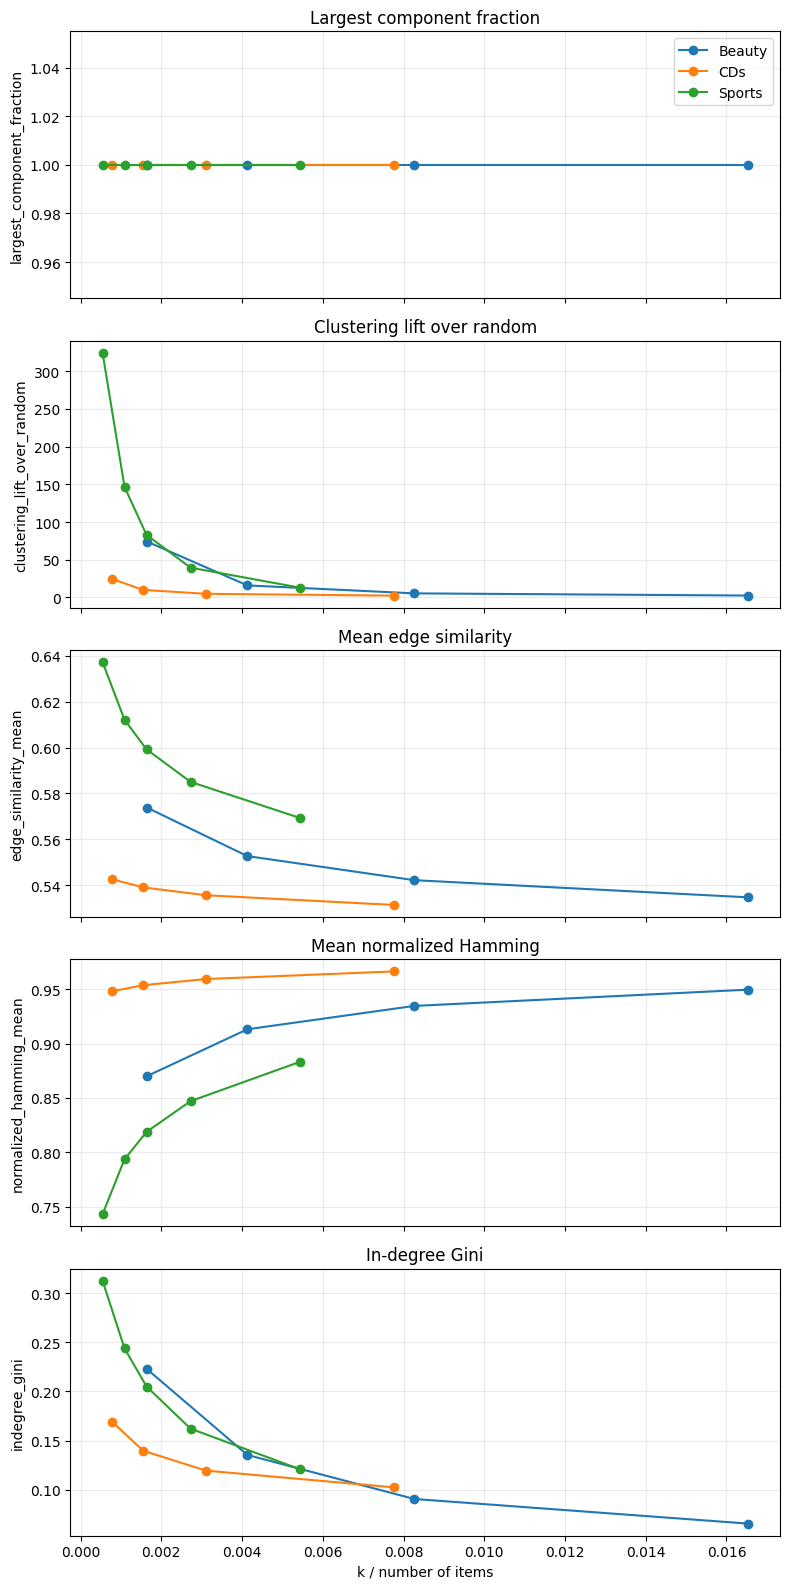

In [3]:
metrics = [
    ("largest_component_fraction", "Largest component fraction"),
    ("clustering_lift_over_random", "Clustering lift over random"),
    ("edge_similarity_mean", "Mean edge similarity"),
    ("normalized_hamming_mean", "Mean normalized Hamming"),
    ("indegree_gini", "In-degree Gini"),
]

if static.empty:
    print("No data to plot yet.")
else:
    available = [(column, title) for column, title in metrics if column in static.columns]
    fig, axes = plt.subplots(len(available), 1, figsize=(8, 3.2 * len(available)), sharex=True)
    if len(available) == 1:
        axes = [axes]
    for axis, (column, title) in zip(axes, available):
        for dataset, group in static.groupby("dataset"):
            axis.plot(group["k_over_items"], group[column], marker="o", label=dataset)
        axis.set_title(title)
        axis.set_ylabel(column)
        axis.grid(alpha=0.25)
    axes[-1].set_xlabel("k / number of items")
    axes[0].legend()
    plt.tight_layout()

## Later Comparisons

- Add dynamic B once multiple datasets have reachability outputs.
- Add graph-vs-brute-force perf once CDs has the same perf-style profiling outputs.
- Keep interpretation short here; detailed explanations belong in each dataset notebook.